# 📊 Olist E-commerce — Análise Exploratória

**Objetivo:** entender receita, comportamento de cliente e impacto da logística na satisfação.

**Etapas:** carregar dados → limpar → analisar → exportar dataset limpo para o Power BI.

> ⚠️ Antes de rodar: baixe os CSVs do [Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) e coloque em `../data/raw/`.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
PROCESSED.mkdir(parents=True, exist_ok=True)

# De-para de categorias (inglês -> português) usado em todo o notebook
traducao_categorias = {
    'toys': 'Brinquedos', 'sports_leisure': 'Esporte e Lazer', 'telephony': 'Telefonia',
    'furniture_decor': 'Móveis e Decoração', 'housewares': 'Utilidades Domésticas',
    'bed_bath_table': 'Cama, Mesa e Banho', 'health_beauty': 'Beleza e Saúde',
    'computers_accessories': 'Informática e Acessórios', 'watches_gifts': 'Relógios e Presentes',
    'auto': 'Automotivo', 'perfumery': 'Perfumaria', 'baby': 'Bebês', 'stationery': 'Papelaria',
    'garden_tools': 'Ferramentas de Jardim', 'fashion_bags_accessories': 'Bolsas e Acessórios',
    'cool_stuff': 'Diversos', 'pet_shop': 'Pet Shop', 'office_furniture': 'Móveis de Escritório',
    'consoles_games': 'Games e Consoles', 'audio': 'Áudio', 'electronics': 'Eletrônicos',
    'food_drink': 'Alimentos e Bebidas', 'small_appliances': 'Eletroportáteis',
    'fashion_shoes': 'Calçados', 'luggage_accessories': 'Malas e Acessórios',
    'home_appliances': 'Eletrodomésticos', 'home_construction': 'Construção',
    'construction_tools_construction': 'Ferramentas de Construção', 'books_general_interest': 'Livros',
    'air_conditioning': 'Ar-Condicionado', 'musical_instruments': 'Instrumentos Musicais',
    'fashion_male_clothing': 'Moda Masculina', 'kitchen_dining_laundry_garden_furniture': 'Móveis de Cozinha',
}

def traduzir_cat(c):
    """Traduz a categoria para PT-BR; se não estiver no de-para, deixa legível."""
    if pd.isna(c):
        return c
    return traducao_categorias.get(c, c.replace('_', ' ').title())

print('Pastas OK. Arquivos em data/raw:')
print([p.name for p in RAW.glob('*.csv')])

Pastas OK. Arquivos em data/raw:
['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


## 2. Carregar os datasets

In [2]:
orders     = pd.read_csv(RAW / 'olist_orders_dataset.csv')
items      = pd.read_csv(RAW / 'olist_order_items_dataset.csv')
payments   = pd.read_csv(RAW / 'olist_order_payments_dataset.csv')
reviews    = pd.read_csv(RAW / 'olist_order_reviews_dataset.csv')
customers  = pd.read_csv(RAW / 'olist_customers_dataset.csv')
products   = pd.read_csv(RAW / 'olist_products_dataset.csv')
cat_trans  = pd.read_csv(RAW / 'product_category_name_translation.csv')

print('orders:', orders.shape)
orders.head()

orders: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## 3. Limpeza e preparação

- Converter colunas de data para datetime.
- Filtrar pedidos entregues (`delivered`).
- Criar métricas de prazo de entrega.

In [3]:
date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors='coerce')

# Apenas pedidos entregues para análises de receita/satisfação
delivered = orders[orders['order_status'] == 'delivered'].copy()

# Prazo de entrega real e atraso vs. estimativa (em dias)
delivered['tempo_entrega_dias'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.days
delivered['atraso_dias'] = (
    delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']
).dt.days

print('Pedidos entregues:', delivered.shape[0])
delivered[['order_id', 'tempo_entrega_dias', 'atraso_dias']].describe()

Pedidos entregues: 96478


,tempo_entrega_dias,atraso_dias
count,96470.000000,96470.000000
mean,12.093604,-11.875889
std,9.551380,10.182105
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-12.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


## 4. Análise 1 — Receita ao longo do tempo

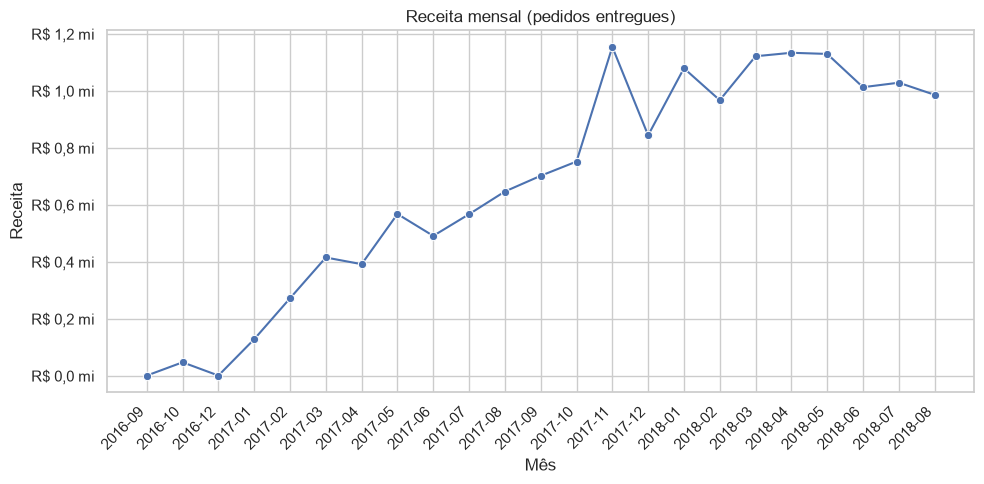

In [4]:
import matplotlib.ticker as mticker

rev = delivered.merge(payments, on='order_id', how='left')
rev['mes'] = rev['order_purchase_timestamp'].dt.to_period('M').astype(str)

receita_mensal = rev.groupby('mes')['payment_value'].sum().reset_index()

ax = sns.lineplot(data=receita_mensal, x='mes', y='payment_value', marker='o')
ax.set_title('Receita mensal (pedidos entregues)')
ax.set_xlabel('Mês'); ax.set_ylabel('Receita')
# Eixo Y como "R$ X,X mi" (vírgula no decimal, padrão BR — em vez da notação científica 1e6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v/1e6:.1f} mi'.replace('.', ',')))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/receita_mensal.png', dpi=120)
plt.show()

## 5. Análise 2 — Top categorias por receita

C:\Users\User\AppData\Local\Temp\ipykernel_35688\109261744.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_cat, y='categoria', x='price', palette='viridis')


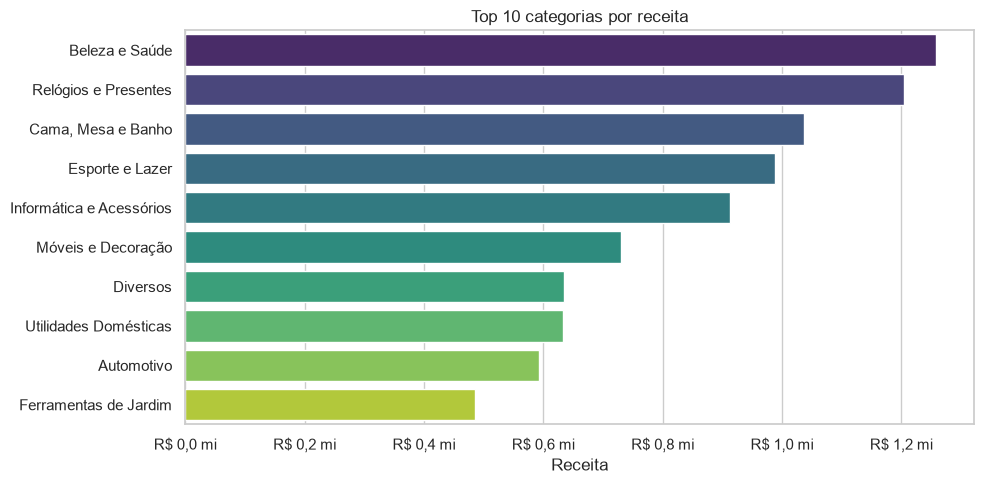

In [5]:
import matplotlib.ticker as mticker

prod = products.merge(cat_trans, on='product_category_name', how='left')
itens_cat = items.merge(prod[['product_id', 'product_category_name_english']], on='product_id', how='left')
itens_cat['categoria'] = itens_cat['product_category_name_english'].apply(traduzir_cat)

top_cat = (itens_cat.groupby('categoria')['price']
           .sum().sort_values(ascending=False).head(10).reset_index())

ax = sns.barplot(data=top_cat, y='categoria', x='price', palette='viridis')
ax.set_title('Top 10 categorias por receita')
ax.set_xlabel('Receita'); ax.set_ylabel('')
# Eixo X como "R$ X,X mi" (vírgula no decimal, padrão BR — em vez de 200000, 400000...)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v/1e6:.1f} mi'.replace('.', ',')))
plt.tight_layout()
plt.savefig('../reports/figures/top_categorias.png', dpi=120)
plt.show()

## 6. Análise 3 — Logística x Satisfação 🔑

_Hipótese: atrasos na entrega derrubam a nota da avaliação._

C:\Users\User\AppData\Local\Temp\ipykernel_35688\2468465121.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=nota_por_faixa, x='faixa_atraso', y='review_score', palette='RdYlGn_r')


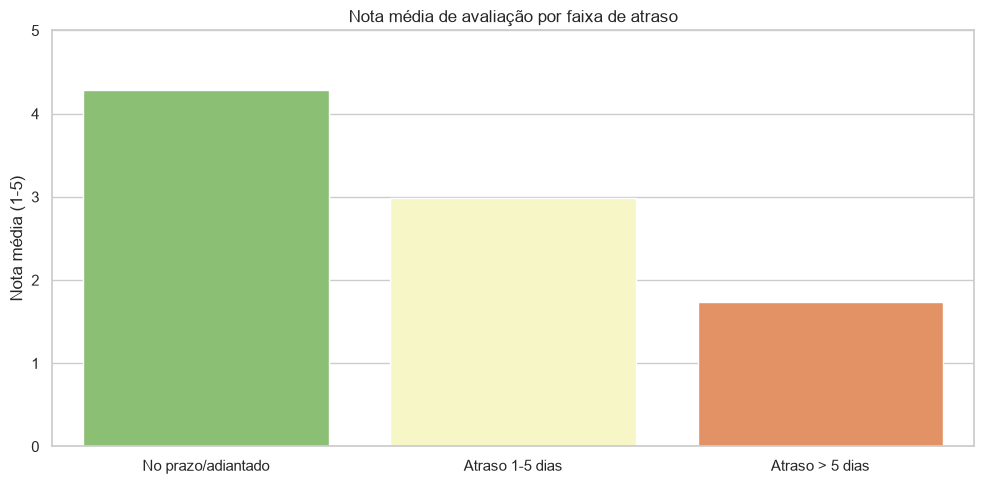

,faixa_atraso,review_score
0,No prazo/adiantado,4.289980
1,Atraso 1-5 dias,2.987541
2,Atraso > 5 dias,1.739674


In [6]:
df = delivered.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')
df = df.dropna(subset=['atraso_dias', 'review_score'])

def faixa(a):
    if a <= 0:  return 'No prazo/adiantado'
    if a <= 5:  return 'Atraso 1-5 dias'
    return 'Atraso > 5 dias'

df['faixa_atraso'] = df['atraso_dias'].apply(faixa)
ordem = ['No prazo/adiantado', 'Atraso 1-5 dias', 'Atraso > 5 dias']

nota_por_faixa = df.groupby('faixa_atraso')['review_score'].mean().reindex(ordem).reset_index()

ax = sns.barplot(data=nota_por_faixa, x='faixa_atraso', y='review_score', palette='RdYlGn_r')
ax.set_title('Nota média de avaliação por faixa de atraso')
ax.set_xlabel(''); ax.set_ylabel('Nota média (1-5)')
ax.set_ylim(0, 5)
plt.tight_layout()
plt.savefig('../reports/figures/atraso_vs_nota.png', dpi=120)
plt.show()
nota_por_faixa

## 7. Análise 4 — Taxa de recompra

In [7]:
ped_cliente = (orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
               .groupby('customer_unique_id')['order_id'].nunique())

total = len(ped_cliente)
recorrentes = (ped_cliente > 1).sum()
print(f'Total de clientes únicos: {total:,}')
print(f'Clientes recorrentes:     {recorrentes:,}')
print(f'Taxa de recompra:         {100*recorrentes/total:.2f}%')

Total de clientes únicos: 96,096
Clientes recorrentes:     2,997
Taxa de recompra:         3.12%


## 8. Exportar dataset limpo para o Power BI

Uma tabela analítica "flat" (uma linha por pedido) pronta para o dashboard.

In [8]:
pay_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()
rev_agg = reviews.groupby('order_id')['review_score'].mean().reset_index()

# Categoria principal de cada pedido (a mais frequente entre os itens), já traduzida
prod_cat = products.merge(cat_trans, on='product_category_name', how='left')
itens_cat2 = items.merge(prod_cat[['product_id', 'product_category_name_english']], on='product_id', how='left')
itens_cat2['categoria'] = itens_cat2['product_category_name_english'].apply(traduzir_cat)
cat_agg = (itens_cat2.groupby('order_id')['categoria']
           .agg(lambda s: s.mode().iat[0] if not s.mode().empty else None)
           .reset_index())

flat = (delivered
        .merge(customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']], on='customer_id', how='left')
        .merge(pay_agg, on='order_id', how='left')
        .merge(rev_agg, on='order_id', how='left')
        .merge(cat_agg, on='order_id', how='left'))

# Coluna "Ano-Mês" (ex: 2017-10) para a linha do tempo contínua no dashboard
flat['ano_mes'] = flat['order_purchase_timestamp'].dt.to_period('M').astype(str)

cols = ['order_id', 'customer_unique_id', 'customer_state', 'customer_city',
        'order_purchase_timestamp', 'ano_mes', 'categoria', 'tempo_entrega_dias', 'atraso_dias',
        'payment_value', 'review_score']
flat = flat[cols]

out = PROCESSED / 'olist_analitico.csv'
flat.to_csv(out, index=False)
print(f'Exportado: {out}  ({flat.shape[0]:,} linhas)')
flat.head()

Exportado: ..\data\processed\olist_analitico.csv  (96,478 linhas)


,order_id,customer_unique_id,customer_state,customer_city,order_purchase_timestamp,ano_mes,categoria,tempo_entrega_dias,atraso_dias,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,2017-10-02 10:56:33,2017-10,Utilidades Domésticas,8.0,-8.0,38.71,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,BA,barreiras,2018-07-24 20:41:37,2018-07,Perfumaria,13.0,-6.0,141.46,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,2018-08-08 08:38:49,2018-08,Automotivo,9.0,-18.0,179.12,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,RN,sao goncalo do amarante,2017-11-18 19:28:06,2017-11,Pet Shop,13.0,-13.0,72.20,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,SP,santo andre,2018-02-13 21:18:39,2018-02,Papelaria,2.0,-10.0,28.62,5.0


## 9. Conclusões e recomendações

Trabalhando com **96 mil pedidos entregues** (R$ 15,4 mi de receita, ticket médio de R$ 159,85 e nota média 4,16):

- **Logística é o que mais pesa na satisfação.** Pedido no prazo tem nota média **4,3**; com atraso acima de 5 dias, a nota despenca para **1,7**. Foi a relação mais clara de toda a análise.
- **A operação cresceu e tem forte sazonalidade.** A receita saiu de ~R$ 130 mil/mês no início de 2017 para o patamar de ~R$ 1 mi/mês em 2018, com pico em **novembro/2017 (R$ 1,15 mi)** — a Black Friday.
- **Poucas categorias concentram o faturamento:** Beleza e Saúde (R$ 1,42 mi), Relógios e Presentes (R$ 1,26 mi) e Cama, Mesa e Banho (R$ 1,24 mi) lideram.
- **Retenção é o ponto fraco:** apenas **3%** dos clientes voltam a comprar — uma base enorme de gente que compra uma vez e some.

**Recomendações:**
1. **Atacar o prazo de entrega** nas rotas mais problemáticas — é o que mais derruba a nota.
2. **Preparar a operação para os picos** (Black Friday e fim de ano), reforçando a logística justamente quando o atraso mais machuca.
3. **Investir em retenção** (pós-venda, cupom de 2ª compra) — com recompra de só 3%, qualquer ganho aqui tem efeito grande no faturamento.